<a href="https://colab.research.google.com/github/Tanmay-Somani/100daysof-code/blob/main/Main_py2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [320]:
import os
import glob
import re
import logging
from datetime import datetime
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random
from torchsummary import summary
from skimage.metrics import peak_signal_noise_ratio as psnr_metric, structural_similarity as ssim_metric
import time
import psutil
import gc
import torch.profiler # Added for profiling

torch.backends.cudnn.benchmark = True # Added for performance optimization

In [321]:
SEQ_LEN = 7
PRED_STEPS = 1
FULL_IMG_SIZE = 1500
IMG_SIZE = 256 # Temporarily reduced for debugging OOM error
BATCH_SIZE = 3
EPOCHS = 2
LR = 5e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED=42
DROPOUT_RATE = 0.2
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
DEBUG_MAX_IMAGES = 60 # Increased from 60 to ensure enough images for all splits

# Profiling Configuration
PROFILE_TRAINING_EPOCH = False # Set to True to enable profiling
PROFILE_NUM_BATCHES = 5 # Number of active batches to profile

In [322]:
BASE_DIR = "/content/project"

os.makedirs(BASE_DIR, exist_ok=True)

DATA_ROOT = f"{BASE_DIR}/data"
LOG_PATH = f"{BASE_DIR}/logs"
LOG_FILE=LOG_PATH+ "/train_cropped.log"
MODEL_PATH = f"{BASE_DIR}/models"
CHKPOINT_DIR = f"{MODEL_PATH}/checkpoints"
IMAGES_DIR = f"{BASE_DIR}/images" # New: Define images directory

for p in [DATA_ROOT, LOG_PATH, MODEL_PATH, CHKPOINT_DIR, IMAGES_DIR]: # New: Add IMAGES_DIR
    os.makedirs(p, exist_ok=True)

In [323]:
# Assuming the image files are directly in DATA_ROOT or a subdirectory like 'colored'
# Adjust the pattern if your image files have a different extension or location
found_images = glob.glob(os.path.join(DATA_ROOT, '**', '*.jpg'), recursive=True) + \
               glob.glob(os.path.join(DATA_ROOT, '**', '*.png'), recursive=True) + \
               glob.glob(os.path.join(DATA_ROOT, '**', '*.jpeg'), recursive=True)

if not found_images:
    print(f"No image files found in {DATA_ROOT}. Please check the path and ensure data is unzipped.")
else:
    print(f"Found {len(found_images)} image files.")
    # Optionally, sort them to ensure consistent sequencing
    found_images.sort()

# Ensure `found_images` is globally accessible
# This line isn't strictly necessary if 'found_images' is defined at the top-level of the script
# but makes its intent explicit for debugging in interactive environments.
global found_images

Found 248 image files.


In [324]:
runno_file_path = LOG_PATH + '/runno.txt'

# Check if runno.txt exists, if not, create it and initialize with 0
if not os.path.exists(runno_file_path):
    with open(runno_file_path, 'w') as f:
        f.write('0')

# Now, read, increment, and write the run number
with open(runno_file_path, 'r') as R:
    runno = int(R.read())
with open(runno_file_path, 'w') as W:
    W.write(str(int(runno + 1)))

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s",
                    handlers=[logging.FileHandler(LOG_FILE),
                              logging.StreamHandler()])

In [325]:
def set_seed(seed):
    """
    Sets the seeds for `random`, `numpy`, and `torch` libraries to ensure reproducibility.

    Args:
        seed (int): The seed value to be used.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [326]:
def parse_datetime(path):
    """
    Parses a datetime string from a file path.

    The file path is expected to be in the format "MMWYY_HHMM" or "MWWYY_HHMM", where:
        - MM: Month as a two-digit number (01-12)
        - W: Weekday (JAN-FEB etc.)
        - YY: Year as a four-digit number
        - HH: Hour in 24-hour format (00-23)
        - MM: Minute (00-59)

    Args:
        path (str): The file path to parse the datetime from.

    Returns:
        datetime: A datetime object representing the parsed date and time.

    Raises:
        ValueError: If the file path does not match the expected format.
    """
    name = os.path.basename(path)
    pattern = r"(\d{2})(\w{3})(\d{4})_(\d{4})"
    match = re.search(pattern, name)
    if not match:
        raise ValueError(f"Bad filename: {name}")
    month_map = {
        'JAN': '01','FEB': '02','MAR': '03','APR': '04','MAY': '05','JUN': '06',
        'JUL': '07','AUG': '08','SEP': '09','OCT': '10','NOV': '11','DEC': '12'
    }
    day=match.group(1)
    month = match.group(2)
    year=match.group(3)
    time=match.group(4)
    for key, value in month_map.items():
        if key in month:
            month = value
            break
    return datetime.strptime(f"{day}{month}{year}.{time}", "%d%m%Y.%H%M")


In [327]:
def mse(p,t):
    """
    Computes the mean squared error (MSE) between two tensors.

    Args:
        p (torch.tensor): The predicted tensor.
        t (torch.tensor): The target tensor.

    Returns:
        torch.tensor: The mean squared error value.
    """
    return torch.mean((p-t)**2)

def rmse(p,t):
    """
    Computes the root mean squared error (RMSE) between two tensors.

    Args:
        p (torch.tensor): The predicted tensor.
        t (torch.tensor): The target tensor.

    Returns:
        torch.tensor: The root mean squared error value.
    """
    return torch.sqrt(mse(p,t)+1e-8)

def mae(p,t):
    """
    Computes the mean absolute error (MAE) between two tensors.

    Args:
        p (torch.tensor): The predicted tensor.
        t (torch.tensor): The mean absolute error value.

    Returns:
        torch.tensor: The mean absolute error value.
    """
    return torch.mean(torch.abs(p-t))

def encode_time(dt):
    """
    Encodes a datetime object into sinusoidal representation.

    The encoding is based on the hour of the day, with values scaled to be between -1 and 1.

    Args:
        dt (datetime): The datetime object to encode.

    Returns:
        tuple: A pair of numpy arrays representing the sine and cosine components of the encoded time.
    """
    hour = dt.hour + dt.minute / 60.0
    sin = np.sin(2 * np.pi * hour / 24)
    cos = np.cos(2 * np.pi * hour / 24)
    return sin, cos

def gradient_loss(pred, target):
    """
    Computes the Gradient Difference Loss (GDL) between prediction and target.
    GDL penalizes differences in image gradients, encouraging sharper predictions.

    Args:
        pred (torch.Tensor): The predicted tensor (B, PRED_STEPS, C, H, W).
        target (torch.Tensor): The target tensor (B, PRED_STEPS, C, H, W).

    Returns:
        torch.Tensor: The GDL value.
    """
    # Calculate gradients along width (x-axis)
    grad_x_pred = torch.abs(pred[:, :, :, :, 1:] - pred[:, :, :, :, :-1])
    grad_x_target = torch.abs(target[:, :, :, :, 1:] - target[:, :, :, :, :-1])
    loss_x = torch.mean(torch.abs(grad_x_pred - grad_x_target))

    # Calculate gradients along height (y-axis)
    grad_y_pred = torch.abs(pred[:, :, :, 1:, :] - pred[:, :, :, :-1, :])
    grad_y_target = torch.abs(target[:, :, :, 1:, :] - target[:, :, :, :-1, :])
    loss_y = torch.mean(torch.abs(grad_y_pred - grad_y_target))

    return loss_x + loss_y

def sobel_filter_loss(pred, target):
    """
    Computes a loss based on the difference of Sobel filtered images.
    This encourages the model to capture edge information more accurately.

    Args:
        pred (torch.Tensor): Predicted tensor (B, PRED_STEPS, C, H, W).
        target (torch.Tensor): Target tensor (B, PRED_STEPS, C, H, W).

    Returns:
        torch.Tensor: The Sobel filter loss value.
    """
    # Define Sobel kernels
    sobel_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]], device=pred.device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]], device=pred.device).view(1, 1, 3, 3)

    # Reshape for convolution: (B * PRED_STEPS, C, H, W)
    # Assuming C=1 for grayscale images, so no change needed there if we're careful
    # Otherwise, you'd convolve over each channel or convert to grayscale for edge detection
    B, T, C, H, W = pred.shape
    pred_reshaped = pred.view(B * T, C, H, W)
    target_reshaped = target.view(B * T, C, H, W)

    # Apply Sobel filters
    grad_x_pred = nn.functional.conv2d(pred_reshaped, sobel_x, padding=1)
    grad_y_pred = nn.functional.conv2d(pred_reshaped, sobel_y, padding=1)
    grad_x_target = nn.functional.conv2d(target_reshaped, sobel_x, padding=1)
    grad_y_target = nn.functional.conv2d(target_reshaped, sobel_y, padding=1)

    # Calculate magnitude of gradients (L1 norm for simplicity, or L2 for smoother)
    pred_edges = torch.sqrt(grad_x_pred**2 + grad_y_pred**2)
    target_edges = torch.sqrt(grad_x_target**2 + grad_y_target**2)

    # Loss is the mean absolute difference between edge maps
    loss = torch.mean(torch.abs(pred_edges - target_edges))
    return loss

def loss_fn(pred, target):
    mse_val = mse(pred, target)
    mae_val = mae(pred, target)
    gdl_val = gradient_loss(pred, target)
    # Removed Sobel calculation
    ssim_val = calculate_ssim(pred, target) # Calculate SSIM

    # Updated total loss calculation with new weights: Boost GDL to 0.15 and SSIM to 0.35
    # Adjusting MSE/MAE to maintain sum of 1: 0.25 * mse_val + 0.25 * mae_val + 0.35 * (1 - ssim_val) + 0.15 * gdl_val
    total_loss = 0.25 * mse_val + 0.25 * mae_val + 0.35 * (1 - ssim_val) + 0.15 * gdl_val

    # Return values without sobel_val
    return total_loss, mse_val.item(), mae_val.item(), gdl_val.item(), ssim_val

def calculate_psnr(p, t):
    "Calculates PSNR between two tensors, handling batch, sequence, and channel dimensions."
    # Ensure tensors are on CPU and converted to numpy, then squeeze redundant dimensions
    p_np = p.detach().cpu().numpy().squeeze()
    t_np = t.detach().cpu().numpy().squeeze()

    if p_np.ndim == 2: # Single image (H, W)
        return psnr_metric(t_np, p_np, data_range=1.0)
    elif p_np.ndim == 3: # Batch of images (B, H, W)
        batch_psnr = [psnr_metric(t_np[i], p_np[i], data_range=1.0) for i in range(p_np.shape[0])]
        return np.mean(batch_psnr)
    else:
        raise ValueError(f"Unexpected number of dimensions for PSNR calculation: {p_np.ndim}")

def calculate_ssim(p, t):
    "Calculates SSIM between two tensors, handling batch, sequence, and channel dimensions."
    # Ensure tensors are on CPU and converted to numpy, then squeeze redundant dimensions
    p_np = p.detach().cpu().numpy().squeeze()
    t_np = t.detach().cpu().numpy().squeeze()

    if p_np.ndim == 2: # Single image (H, W)
        ssim_value = ssim_metric(t_np, p_np, data_range=1.0)
    elif p_np.ndim == 3: # Batch of images (B, H, W)
        batch_ssim = [ssim_metric(t_np[i], p_np[i], data_range=1.0) for i in range(p_np.shape[0])]
        ssim_value = np.mean(batch_ssim)
    else:
        raise ValueError(f"Unexpected number of dimensions for SSIM calculation: {p_np.ndim}")

    return torch.tensor(ssim_value, dtype=torch.float32, device=p.device)

In [328]:
def plot_metrics(hist):
    """Plots training, validation, and test metrics (Loss, PSNR, SSIM, MAE, MSE, RMSE, GDL) from the history dictionary."""

    metrics_to_plot = [
        ('loss', 'Loss', 'r'),
        ('psnr', 'PSNR', 'g'),
        ('ssim', 'SSIM', 'purple'),
        ('mae', 'Mean Absolute Error', 'orange'),
        ('mse', 'Mean Squared Error', 'brown'),
        ('rmse', 'Root Mean Squared Error', 'cyan'),
        ('gdl', 'Gradient Difference Loss', 'magenta')
    ]

    for metric_key, metric_name, test_color in metrics_to_plot:
        plt.figure(figsize=(10, 6))
        plt.plot(hist[f'train_{metric_key}'], label=f'Training {metric_name}')
        plt.plot(hist[f'val_{metric_key}'], label=f'Validation {metric_name}')

        # Check if test metric is available and plot it
        if f'test_{metric_key}' in hist and hist[f'test_{metric_key}']:
            if len(hist[f'test_{metric_key}']) == 1:
                plt.axhline(y=hist[f'test_{metric_key}'][0], color=test_color, linestyle='--', label=f'Test {metric_name}')
            else:
                plt.plot(hist[f'test_{metric_key}'], label=f'Test {metric_name}')

        plt.title(f'Training, Validation, and Test {metric_name} Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel(metric_name)
        plt.legend()
        plt.grid(True)
        plt.show()

def plot_activation_statistics(hist, model):
    """Plots activation statistics (mean, max, std) for ConvLSTM layers from the history dictionary."""
    stats_types = ['mean', 'max', 'std']
    layer_prefixes = ['encoder', 'decoder']

    for stat_type in stats_types:
        for prefix in layer_prefixes:
            num_layers = len(model.encoder_convlstm_cells) if prefix == 'encoder' else len(model.decoder_convlstm_cells)
            for i in range(num_layers):
                key_base = f'{prefix}_l{i}_h_{stat_type}'
                train_key = f'train_{key_base}'
                val_key = f'val_{key_base}'

                if train_key in hist and hist[train_key] and val_key in hist and hist[val_key]:
                    plt.figure(figsize=(10, 6))
                    plt.plot(hist[train_key], label=f'Training {prefix} Layer {i} {stat_type.capitalize()} H')
                    plt.plot(hist[val_key], label=f'Validation {prefix} Layer {i} {stat_type.capitalize()} H')
                    plt.title(f'{prefix} Layer {i} Hidden State {stat_type.capitalize()} Over Epochs')
                    plt.xlabel('Epoch')
                    plt.ylabel(f'Activation {stat_type.capitalize()}')
                    plt.legend()
                    plt.grid(True)
                    plt.show()
                else:
                    logging.warning(f"Data for {key_base} not found in history. Skipping plot.")

def plot_error_vs_pixel_intensity(all_test_preds, all_test_targets, num_bins=10):
    """
    Plots the average pixel-wise absolute error against target pixel intensity bins.

    Args:
        all_test_preds (list[torch.Tensor]): List of predicted tensors from the test set.
        all_test_targets (list[torch.Tensor]): List of target tensors from the test set.
        num_bins (int): Number of bins for pixel intensity.
    """
    if not all_test_preds or not all_test_targets:
        logging.warning("No test predictions or targets available for error vs pixel intensity plot.")
        return

    # Concatenate all predictions and targets into single tensors
    preds_flat = torch.cat([p.flatten() for p in all_test_preds]).cpu().numpy()
    targets_flat = torch.cat([t.flatten() for t in all_test_targets]).cpu().numpy()

    # Calculate absolute pixel-wise errors
    errors = np.abs(preds_flat - targets_flat)

    # Define intensity bins (0.0 to 1.0)
    bins = np.linspace(0.0, 1.0, num_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    mean_errors_per_bin = []
    for i in range(num_bins):
        # Find pixels whose target intensity falls into the current bin
        if i == num_bins - 1:
            # For the last bin, include the upper bound (1.0)
            bin_mask = (targets_flat >= bins[i]) & (targets_flat <= bins[i+1])
        else:
            bin_mask = (targets_flat >= bins[i]) & (targets_flat < bins[i+1])

        if np.any(bin_mask):
            mean_errors_per_bin.append(np.mean(errors[bin_mask]))
        else:
            mean_errors_per_bin.append(np.nan) # Append NaN if no pixels in bin

    # Filter out NaNs for plotting
    valid_bin_centers = [bc for bc, me in zip(bin_centers, mean_errors_per_bin) if not np.isnan(me)]
    valid_mean_errors = [me for me in mean_errors_per_bin if not np.isnan(me)]

    if not valid_bin_centers:
        logging.warning("No valid data points to plot for error vs pixel intensity.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(valid_bin_centers, valid_mean_errors, marker='o', linestyle='-', color='blue')
    plt.title('Average Absolute Pixel Error vs. Target Pixel Intensity')
    plt.xlabel('Target Pixel Intensity (Bin Center)')
    plt.ylabel('Average Absolute Error')
    plt.grid(True)
    plt.ylim(bottom=0) # Ensure y-axis starts at 0
    plt.show()

### Learning Rate Plot

In [329]:
def plot_learning_rate(hist):
    """Plots the learning rate over epochs from the history dictionary."""
    if 'lr' in hist and hist['lr']:
        plt.figure(figsize=(10, 6))
        plt.plot(hist['lr'], label='Learning Rate')
        plt.title('Learning Rate Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        logging.warning("Learning rate data not found in history. Cannot plot learning rate.")

### Prediction Distribution Plots

In [330]:
def plot_prediction_statistics(hist):
    """Plots min, max, mean, and std of predictions for train and validation sets."""

    pred_stats = [
        ('pred_min', 'Prediction Minimum'),
        ('pred_max', 'Prediction Maximum'),
        ('pred_mean', 'Prediction Mean'),
        ('pred_std', 'Prediction Standard Deviation')
    ]

    for stat_key, stat_name in pred_stats:
        plt.figure(figsize=(10, 6))
        if f'train_{stat_key}' in hist and hist[f'train_{stat_key}']:
            plt.plot(hist[f'train_{stat_key}'], label=f'Training {stat_name}')
        if f'val_{stat_key}' in hist and hist[f'val_{stat_key}']:
            plt.plot(hist[f'val_{stat_key}'], label=f'Validation {stat_name}')

        if (f'train_{stat_key}' in hist and hist[f'train_{stat_key}']) or \
           (f'val_{stat_key}' in hist and hist[f'val_{stat_key}']):
            plt.title(f'{stat_name} Over Epochs')
            plt.xlabel('Epoch')
            plt.ylabel(stat_name)
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            logging.warning(f"No data found for {stat_name}. Skipping plot.")

In [331]:
class SpatioTemporalDataset(Dataset):
    """
    Initializes the SpatioTemporalDataset class.

    Args:
        image_paths (list): A list of image file paths for the dataset.
        is_train (bool): Flag to indicate if the dataset is for training (enables augmentation).

    Note:
        This function takes pre-sorted image paths and creates a list of tuples containing input and target sequences.

    Attributes:
        samples (list[tuple]): A list of tuples, where each tuple contains an input sequence and a corresponding target sequence.
    """
    def __init__(self, image_paths, is_train=True):
        self.image_paths = image_paths
        self.samples = []
        self.is_train = is_train
        total_len = SEQ_LEN + PRED_STEPS

        for i in range(len(self.image_paths) - total_len):
            window = self.image_paths[i:i+total_len]
            inp = window[:SEQ_LEN]
            tgt = window[SEQ_LEN:]
            self.samples.append((inp, tgt))

        logging.info(f"Total valid samples for this split: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def load_img(self, path):
        """
        Load an image from a file.

        Args:
            path (str): The path to the image file.

        Returns:
            np.ndarray: The loaded image.
        """
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        # Determine interpolation method based on whether image is being upscaled or downscaled
        h_orig, w_orig = img.shape[:2]
        if IMG_SIZE > h_orig or IMG_SIZE > w_orig:
            # Upscaling
            interpolation_method = cv2.INTER_CUBIC
        else:
            # Downscaling or no change
            interpolation_method = cv2.INTER_AREA

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE),
            interpolation=interpolation_method
        )
        img = img / 255.0
        return img

    def _add_gaussian_noise(self, image, mean=0., std=0.01):
        """
        Adds Gaussian noise to an image.
        """
        noise = np.random.normal(mean, std, image.shape)
        noisy_image = image + noise
        return np.clip(noisy_image, 0.0, 1.0)

    def _adjust_brightness(self, image, brightness_factor=0.1):
        """
        Adjusts the brightness of an image.
        """
        return np.clip(image + brightness_factor * (np.random.rand() * 2 - 1), 0.0, 1.0)

    def _augment_image(self, image, noise_std, brightness_factor):
        """
        Applies Gaussian noise and brightness shift to an image.
        """
        augmented_image = self._add_gaussian_noise(image, std=noise_std)
        augmented_image = self._adjust_brightness(augmented_image, brightness_factor=brightness_factor)
        return augmented_image

    def __getitem__(self, idx):
        seq = []
        targets = []
        inp_paths, tgt_paths = self.samples[idx]

        # Generate augmentation parameters once per sequence if in training mode
        noise_std = np.random.uniform(0.005, 0.02) if self.is_train else 0.0
        brightness_shift = np.random.uniform(-0.05, 0.05) if self.is_train else 0.0

        for p in inp_paths:
            img = self.load_img(p)
            if self.is_train:
                img = self._augment_image(img, noise_std, brightness_shift)

            dt = parse_datetime(p)
            sin, cos = encode_time(dt)
            time_map = np.ones_like(img)
            stacked = np.stack(
                [
                    img,
                    sin * time_map,
                    cos * time_map
                ],
                axis=0
            )
            seq.append(stacked)
        seq = np.stack(seq, axis=0)

        for p in tgt_paths:
            img = self.load_img(p)
            # Augment target frames with the same parameters as input frames
            # Removed augmentation for target frames as they should be ground truth
            targets.append(np.expand_dims(img, axis=0))
        targets = np.stack(targets, axis=0)
        return torch.tensor(seq, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32)

In [332]:
class ConvLSTMCell(nn.Module):
    """
    A 2D Convolutional LSTM Cell.

    Attributes:
        hidden_dim (int): The number of output features in the cell.
        conv (nn.Conv2d): The convolutional layer that combines input and hidden state.

    Methods:
        forward(x, h, c): The forward pass through the cell.
    """
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(
        in_dim + hidden_dim,
        4 * hidden_dim,
        3,
        padding=1
        )
        # Replaced BatchNorm2d with LayerNorm
        # LayerNorm needs to be applied after permuting dimensions to (B, H, W, C)
        self.ln = nn.LayerNorm(4 * hidden_dim)

    def forward(self, x, h, c):
        """
        The forward pass through the cell.

        Args:
            x (torch.Tensor): The input tensor.
            h (torch.Tensor): The current hidden state.
            c (torch.Tensor): The current cell state.

        Returns:
            tuple: A tuple containing the updated hidden and cell states.
        """

        combined = torch.cat([x, h], dim=1)
        out = self.conv(combined)

        # Apply LayerNorm: permute to (B, H, W, C), apply LN, then permute back
        out = out.permute(0, 2, 3, 1).contiguous() # (B, H, W, C)
        out = self.ln(out)
        out = out.permute(0, 3, 1, 2).contiguous() # (B, C, H, W)

        i, f, o, g = torch.chunk(out, 4, dim=1)
        i=torch.sigmoid(i)
        f=torch.sigmoid(f)
        o=torch.sigmoid(o)
        g=torch.tanh(g)
        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c

# =========================
# SPATIAL ATTENTION MODULE
# =========================
class SpatialAttention(nn.Module):
    """
    A lightweight spatial attention module.
    It processes the input feature map to generate spatial attention weights.
    """
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels // 2, kernel_size=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels // 2, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        Forward pass for the spatial attention module.
        Args:
            x (torch.Tensor): Input feature map (B, C, H, W).
        Returns:
            torch.Tensor: Attention-weighted feature map (B, C, H, W).
        """
        attn_weights = self.conv1(x)
        attn_weights = self.relu(attn_weights)
        attn_weights = self.conv2(attn_weights)
        attn_weights = self.sigmoid(attn_weights) # Output (B, 1, H, W)
        return x * attn_weights # Apply attention as a multiplicative mask

# =========================
# SQUEEZE-AND-EXCITATION BLOCK (Channel Attention)
# =========================
class SEBlock(nn.Module):
    """
    A Squeeze-and-Excitation (SE) block for channel-wise attention.
    It adaptively recalibrates channel-wise feature responses.
    """
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1) # Global average pooling

        # Ensure reduced_channels is at least 1 to avoid zero-dimension errors
        reduced_channels = max(1, channel // reduction)

        self.fc = nn.Sequential(
            nn.Linear(channel, reduced_channels, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced_channels, channel, bias=False),
            nn.Sigmoid() # Scale values between 0 and 1
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).reshape(b, c) # Squeeze operation
        y = self.fc(y).reshape(b, c, 1, 1) # Excitation operation and reshape
        return x * y.expand_as(x)


# =========================
# MODEL (Encoder-Decoder ConvLSTM with new architecture)
# =========================
class ConvLSTMModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.relu = nn.ReLU()

        # Encoder path
        # Level 1 (Full Res)
        self.conv_in = nn.Conv2d(3, 32, kernel_size=3, padding=1) # Input (C=3) to 32 channels
        # Level 2 (Half Res)
        self.pool1 = nn.MaxPool2d(2, 2) # Downsample H, W by 2
        self.conv_mid = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32 channels to 64 channels
        # Level 3 (Quarter Res) - input to ConvLSTM
        self.pool2 = nn.MaxPool2d(2, 2) # Downsample H, W by 2 again
        self.conv_deep = nn.Conv2d(64, 256, kernel_size=3, padding=1) # 64 channels to 256 channels

        # Encoder ConvLSTM part (takes 256 channels from conv_deep)
        self.encoder_convlstm_hidden_dims = [256, 256] # Two layers with 256 hidden_dim each
        self.encoder_convlstm_cells = nn.ModuleList()
        self.encoder_convlstm_cells.append(ConvLSTMCell(256, self.encoder_convlstm_hidden_dims[0]))
        for i in range(1, len(self.encoder_convlstm_hidden_dims)):
            self.encoder_convlstm_cells.append(ConvLSTMCell(self.encoder_convlstm_hidden_dims[i-1], self.encoder_convlstm_hidden_dims[i]))

        # Decoder ConvLSTM part
        self.decoder_convlstm_hidden_dims = [256, 256] # Two layers with 256 hidden_dim each
        self.decoder_convlstm_cells = nn.ModuleList()
        self.decoder_convlstm_cells.append(ConvLSTMCell(self.encoder_convlstm_hidden_dims[-1], self.decoder_convlstm_hidden_dims[0]))
        for i in range(1, len(self.decoder_convlstm_hidden_dims)):
            self.decoder_convlstm_cells.append(ConvLSTMCell(self.decoder_convlstm_hidden_dims[i-1], self.decoder_convlstm_hidden_dims[i]))

        # Modules applied *after* the decoder ConvLSTM for each prediction step
        self.se_block = SEBlock(channel=self.decoder_convlstm_hidden_dims[-1]) # applied to decoder_h (256 channels)
        self.spatial_attention = SpatialAttention(self.decoder_convlstm_hidden_dims[-1]) # applied after SE (256 channels)

        # Decoder path (upsampling with skip connections)
        # Level 2 Upsample
        self.upconv2 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2) # Upsample H/4,W/4 to H/2,W/2
        self.dec_conv2 = nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1) # Combine with skip connection from conv_mid

        # Level 1 Upsample
        self.upconv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2) # Upsample H/2,W/2 to H,W
        self.dec_conv1 = nn.Conv2d(32 + 32, 32, kernel_size=3, padding=1) # Combine with skip connection from conv_in

        # Final output convolution (from previous change)
        self.final_output_conv = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1), # Intermediate 3x3 conv
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=1) # Final 1x1 conv
        )

        self.dropout = nn.Dropout2d(p=dropout_rate)

    def _get_activation_statistics(self, h_state):
        # Flatten spatial dimensions and average over batch
        h_flat = h_state.reshape(h_state.size(0), h_state.size(1), -1) # B, C, H*W
        mean = h_flat.mean(dim=[0, 2]) # Mean over batch and spatial, keeps channel dim
        std = h_flat.std(dim=[0, 2])
        max_val = h_flat.max(dim=-1)[0].mean(dim=0) # Max over spatial, then mean over batch
        return mean, max_val, std

    def forward(self, x):
        B, T_enc, C, H, W = x.shape

        last_input_frame = x[:, T_enc - 1, 0, :, :].unsqueeze(1) # Shape (B, 1, H, W)

        # Initialize lists to store encoder outputs for skip connections and ConvLSTM inputs
        encoder_convlstm_inputs = []
        last_encoder_output_level1 = None
        last_encoder_output_level2 = None

        for t in range(T_enc):
            frame = x[:, t] # (B, C=3, H, W)

            # Level 1 (Full Res)
            conv_in_output = self.relu(self.conv_in(frame))
            if t == T_enc - 1: # Only store the last frame's output for skip connection
                last_encoder_output_level1 = conv_in_output

            # Level 2 (Half Res)
            pooled1_output = self.pool1(conv_in_output)
            conv_mid_output = self.relu(self.conv_mid(pooled1_output))
            if t == T_enc - 1: # Only store the last frame's output for skip connection
                last_encoder_output_level2 = conv_mid_output

            # Level 3 (Quarter Res) - input to ConvLSTM
            pooled2_output = self.pool2(conv_mid_output)
            conv_deep_output = self.relu(self.conv_deep(pooled2_output))
            encoder_convlstm_inputs.append(conv_deep_output) # Store for each timestep

        # Initialize Encoder ConvLSTM hidden and cell states
        encoder_h_c_states = []
        H_convlstm, W_convlstm = H // 4, W // 4 # Dimensions after two downsamplings
        for hidden_dim in self.encoder_convlstm_hidden_dims:
            encoder_h_c_states.append((
                torch.zeros(B, hidden_dim, H_convlstm, W_convlstm, device=x.device),
                torch.zeros(B, hidden_dim, H_convlstm, W_convlstm, device=x.device)
            ))

        encoder_h_stats = { 'mean': [None] * len(self.encoder_convlstm_cells),
                            'max': [None] * len(self.encoder_convlstm_cells),
                            'std': [None] * len(self.encoder_convlstm_cells) }

        # Run Encoder ConvLSTM
        for t in range(T_enc):
            current_layer_input_convlstm = encoder_convlstm_inputs[t] # Use the correct input for each timestep

            for i, cell in enumerate(self.encoder_convlstm_cells):
                h, c = cell(current_layer_input_convlstm, encoder_h_c_states[i][0], encoder_h_c_states[i][1])
                if self.training:
                    h = self.dropout(h)
                encoder_h_c_states[i] = (h, c)
                current_layer_input_convlstm = h # Output of current layer becomes input for next layer

                # Capture stats only for the last timestep of the encoder
                if t == T_enc - 1:
                    mean, max_val, std = self._get_activation_statistics(h)
                    encoder_h_stats['mean'][i] = mean
                    encoder_h_stats['max'][i] = max_val
                    encoder_h_stats['std'][i] = std

        # Decoder pass: Use final encoder states to initialize decoder ConvLSTM
        decoder_h_c_states = list(encoder_h_c_states) # Initialize decoder states with final encoder states

        outputs = []
        decoder_input_for_first_layer = decoder_h_c_states[-1][0] # (B, 256, H/4, W/4)

        # Get skip connection sources from the *last* encoder input frame
        skip_feature_level1 = last_encoder_output_level1 # (B, 32, H, W)
        skip_feature_level2 = last_encoder_output_level2 # (B, 64, H/2, W/2)

        decoder_h_stats = { 'mean': [None] * len(self.decoder_convlstm_cells),
                            'max': [None] * len(self.decoder_convlstm_cells),
                            'std': [None] * len(self.decoder_convlstm_cells) }

        for t_pred in range(PRED_STEPS):
            current_layer_input = decoder_input_for_first_layer

            for i, cell in enumerate(self.decoder_convlstm_cells):
                h, c = cell(current_layer_input, decoder_h_c_states[i][0], decoder_h_c_states[i][1])
                if self.training:
                    h = self.dropout(h)
                decoder_h_c_states[i] = (h, c)
                current_layer_input = h # Output of current layer becomes input for next layer

                # Capture stats only for the first predicted timestep of the decoder
                if t_pred == 0:
                    mean, max_val, std = self._get_activation_statistics(h)
                    decoder_h_stats['mean'][i] = mean
                    decoder_h_stats['max'][i] = max_val
                    decoder_h_stats['std'][i] = std

            # After decoder ConvLSTM, apply post-processing modules for each predicted frame
            decoder_final_h = decoder_h_c_states[-1][0] # (B, 256, H/4, W/4)

            se_refined_h = self.se_block(decoder_final_h) # (B, 256, H/4, W/4)
            attended_h = self.spatial_attention(se_refined_h) # (B, 256, H/4, W/4)

            # Level 2 Upsample with skip connection
            upsampled_h2 = self.upconv2(attended_h) # (B, 64, H/2, W/2)
            combined_features_level2 = torch.cat([upsampled_h2, skip_feature_level2], dim=1) # (B, 64+64, H/2, W/2)
            processed_features_level2 = self.relu(self.dec_conv2(combined_features_level2)) # (B, 64, H/2, W/2)

            # Level 1 Upsample with skip connection
            upsampled_h1 = self.upconv1(processed_features_level2) # (B, 32, H, W)
            combined_features_level1 = torch.cat([upsampled_h1, skip_feature_level1], dim=1) # (B, 32+32, H, W)
            processed_features_level1 = self.relu(self.dec_conv1(combined_features_level1)) # (B, 32, H, W)

            # Residual prediction
            predicted_change = self.final_output_conv(processed_features_level1)
            predicted_frame = torch.clamp(last_input_frame + predicted_change, 0, 1) # (B, 1, H, W)
            outputs.append(predicted_frame)

        return torch.stack(outputs, dim=1), encoder_h_stats, decoder_h_stats # Return outputs and activation stats

In [333]:
# Removed redundant model initialization here. Model is now initialized within run_experiment.

In [334]:
model = ConvLSTMModel(dropout_rate=DROPOUT_RATE).to(DEVICE) # Initialize dummy model for summary
model.eval()

current_img_size_for_summary = IMG_SIZE
dummy_input_size = (BATCH_SIZE, SEQ_LEN, 3, current_img_size_for_summary, current_img_size_for_summary)
print(f"Generating model summary with input size: {dummy_input_size}")
print(f"Current IMG_SIZE value used for summary: {current_img_size_for_summary}")

try:
    summary(model, input_size=(SEQ_LEN, 3, current_img_size_for_summary, current_img_size_for_summary))
except RuntimeError as e:
    print(f"Error generating summary: {e}. This might happen if the input size is too large for GPU memory.")

Generating model summary with input size: (3, 7, 3, 256, 256)
Current IMG_SIZE value used for summary: 256
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             896
              ReLU-2         [-1, 32, 256, 256]               0
         MaxPool2d-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 64, 128, 128]          18,496
              ReLU-5         [-1, 64, 128, 128]               0
         MaxPool2d-6           [-1, 64, 64, 64]               0
            Conv2d-7          [-1, 256, 64, 64]         147,712
              ReLU-8          [-1, 256, 64, 64]               0
            Conv2d-9         [-1, 32, 256, 256]             896
             ReLU-10         [-1, 32, 256, 256]               0
        MaxPool2d-11         [-1, 32, 128, 128]               0
           Conv2d-12         [-1, 64, 128, 128]          18,

In [335]:
def save_predictions(predicted_frames_tensor, target_frames_tensor, epoch, split_name="", sample_idx=0): # num_samples removed as we iterate through batch
    """
    Saves predicted and target frames as images to a specified directory.
    Also saves a heatmap of the absolute difference between predicted and target frames.

    Args:
        predicted_frames_tensor (torch.Tensor): The predicted frames tensor (B, PRED_STEPS, C, H, W).
        target_frames_tensor (torch.Tensor): The target frames tensor (B, PRED_STEPS, C, H, W).
        epoch (int): The current epoch number.
        split_name (str): The name of the data split (e.g., 'train', 'val', 'test').
        sample_idx (int): The starting index of the sample within the batch (for naming).
    """
    # Ensure IMAGES_DIR exists
    if not os.path.exists(IMAGES_DIR):
        os.makedirs(IMAGES_DIR)

    # Convert tensors to numpy arrays (0-1 range for difference calculation)
    predicted_float = predicted_frames_tensor.detach().cpu().numpy()
    target_float = target_frames_tensor.detach().cpu().numpy()

    # Create a directory for this epoch's predictions if it doesn't exist
    epoch_dir = os.path.join(IMAGES_DIR, f"epoch_{epoch}")
    if not os.path.exists(epoch_dir):
        os.makedirs(epoch_dir)

    # Iterate through each item in the batch
    for i in range(predicted_float.shape[0]):
        # Squeeze to handle (PRED_STEPS, H, W) or (H, W) if PRED_STEPS is 1
        current_pred_frame = predicted_float[i].squeeze() # shape (H, W)
        current_target_frame = target_float[i].squeeze() # shape (H, W)

        # Convert to uint8 for saving images (scale to 0-255)
        pred_img_uint8 = (current_pred_frame * 255).astype(np.uint8)
        target_img_uint8 = (current_target_frame * 255).astype(np.uint8)

        # Save predicted frame
        # Use (sample_idx + i) for unique naming across all batches
        pred_filename = os.path.join(epoch_dir, f"{split_name}_pred_e{epoch}_s{sample_idx+i}.png")
        cv2.imwrite(pred_filename, pred_img_uint8)

        # Save target frame
        target_filename = os.path.join(epoch_dir, f"{split_name}_target_e{epoch}_s{sample_idx+i}.png")
        cv2.imwrite(target_filename, target_img_uint8)

        # Calculate and save difference heatmap
        diff_img = np.abs(current_pred_frame - current_target_frame)

        # Plotting the heatmap
        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(diff_img, cmap='jet', vmin=0, vmax=1) # Use jet colormap for colored heatmap
        ax.set_title(f'Difference Heatmap (Epoch {epoch}, Sample {sample_idx+i})')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04) # Add colorbar
        ax.axis('off') # Remove axes for cleaner image
        diff_filename = os.path.join(epoch_dir, f"{split_name}_diff_heatmap_e{epoch}_s{sample_idx+i}.png")
        plt.savefig(diff_filename, bbox_inches='tight', pad_inches=0)
        plt.close(fig) # Close the figure to free memory

    logging.debug(f"Saved {predicted_float.shape[0]} prediction(s), target(s), and difference heatmap(s) for epoch {epoch}, split {split_name} starting at sample {sample_idx} to {epoch_dir}/")

In [336]:
def get_resource_usage(stage_name):
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    cpu_percent = process.cpu_percent(interval=None) # Non-blocking call
    logging.info(f"[{stage_name} Resource Usage] CPU: {cpu_percent:.2f}% | RAM: {mem_info.rss / (1024 ** 2):.2f} MB")
    if DEVICE == 'cuda':
        try:
            logging.info(f"[{stage_name} Resource Usage] GPU Memory Allocated: {torch.cuda.memory_allocated() / (1024 ** 2):.2f} MB | GPU Memory Cached: {torch.cuda.memory_reserved() / (1024 ** 2):.2f} MB")
        except RuntimeError as e:
            logging.warning(f"Could not get GPU memory usage: {e}")

def train_epoch(model, train_loader, opt, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim, scheduler, profiler=None):
    start_time_epoch = time.time()
    model.train()
    train_totals = {k: 0 for k in ["loss", "mae", "mse", "rmse", "psnr", "ssim", "gdl", "pred_min", "pred_max", "pred_mean", "pred_std"]}

    # Add placeholders for activation statistics for each encoder and decoder ConvLSTM layer
    for i in range(len(model.encoder_convlstm_cells)):
        train_totals[f"encoder_l{i}_h_mean"] = 0
        train_totals[f"encoder_l{i}_h_max"] = 0
        train_totals[f"encoder_l{i}_h_std"] = 0
    for i in range(len(model.decoder_convlstm_cells)):
        train_totals[f"decoder_l{i}_h_mean"] = 0
        train_totals[f"decoder_l{i}_h_max"] = 0
        train_totals[f"decoder_l{i}_h_std"] = 0

    train_cnt = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")

    for batch_idx, (x, y) in enumerate(pbar):
        start_time_batch = time.time()
        x, y = x.to(DEVICE), y.to(DEVICE)

        pred, encoder_h_stats, decoder_h_stats = model(x) # Unpack new return values
        # Updated unpacking for loss_fn return values (removed sobel_val)
        total_loss, mse_val, mae_val, gdl_val, ssim_val = loss_fn(pred, y)

        total_loss.backward() # Perform backward pass

        opt.step() # Update optimizer
        opt.zero_grad() # Zero gradients after optimization step

        if profiler is not None: # Step the profiler if enabled
            profiler.step()

        with torch.no_grad():
            train_totals["loss"] += total_loss.item()
            train_totals["mae"] += mae_val
            train_totals["mse"] += mse_val
            train_totals["rmse"] += rmse(pred, y).item()
            train_totals["psnr"] += calculate_psnr(pred, y)
            train_totals["ssim"] += ssim_val # Added SSIM value
            train_totals["gdl"] += gdl_val
            train_totals["pred_min"] += pred.min().item()
            train_totals["pred_max"] += pred.max().item()
            train_totals["pred_mean"] += pred.mean().item()
            train_totals["pred_std"] += pred.std().item()

            # Aggregate activation statistics
            for i in range(len(model.encoder_convlstm_cells)):
                train_totals[f"encoder_l{i}_h_mean"] += encoder_h_stats['mean'][i].mean().item()
                train_totals[f"encoder_l{i}_h_max"] += encoder_h_stats['max'][i].mean().item()
                train_totals[f"encoder_l{i}_h_std"] += encoder_h_stats['std'][i].mean().item()
            for i in range(len(model.decoder_convlstm_cells)):
                train_totals[f"decoder_l{i}_h_mean"] += decoder_h_stats['mean'][i].mean().item()
                train_totals[f"decoder_l{i}_h_max"] += decoder_h_stats['max'][i].mean().item()
                train_totals[f"decoder_l{i}_h_std"] += decoder_h_stats['std'][i].mean().item()

            train_cnt += 1

        pbar.set_postfix(loss=total_loss.item())
        end_time_batch = time.time()
        logging.debug(f"Epoch {epoch+1} [Train] Batch Time: {end_time_batch - start_time_batch:.4f}s")
        get_resource_usage(f"Epoch {epoch+1} [Train] Batch")

    # Keys for general metrics
    general_metrics = ["loss", "mae", "mse", "rmse", "psnr", "ssim", "gdl", "pred_min", "pred_max", "pred_mean", "pred_std"]
    for k in general_metrics:
        hist[f"train_{k}"].append(train_totals[k] / train_cnt if train_cnt > 0 else 0)

    # Keys for activation statistics
    for i in range(len(model.encoder_convlstm_cells)):
        hist[f"train_encoder_l{i}_h_mean"].append(train_totals[f"encoder_l{i}_h_mean"] / train_cnt if train_cnt > 0 else 0)
        hist[f"train_encoder_l{i}_h_max"].append(train_totals[f"encoder_l{i}_h_max"] / train_cnt if train_cnt > 0 else 0)
        hist[f"train_encoder_l{i}_h_std"].append(train_totals[f"encoder_l{i}_h_std"] / train_cnt if train_cnt > 0 else 0)
    for i in range(len(model.decoder_convlstm_cells)):
        hist[f"train_decoder_l{i}_h_mean"].append(train_totals[f"decoder_l{i}_h_mean"] / train_cnt if train_cnt > 0 else 0)
        hist[f"train_decoder_l{i}_h_max"].append(train_totals[f"decoder_l{i}_h_max"] / train_cnt if train_cnt > 0 else 0)
        hist[f"train_decoder_l{i}_h_std"].append(train_totals[f"decoder_l{i}_h_std"] / train_cnt if train_cnt > 0 else 0)

    hist['lr'].append(scheduler.get_last_lr()[0]) # Log learning rate
    scheduler.step() # Update learning rate at the end of the epoch
    logging.info(f"Epoch {epoch+1} [Train] Learning Rate: {hist['lr'][-1]:.6f}")
    end_time_epoch = time.time()
    logging.info(f"Epoch {epoch+1} [Train] Avg Loss: {hist['train_loss'][-1]:.4f}, MAE: {hist['train_mae'][-1]:.4f}, PSNR: {hist['train_psnr'][-1]:.4f}, SSIM: {hist['train_ssim'][-1]:.4f}, GDL: {hist['train_gdl'][-1]:.4f}) | Duration: {end_time_epoch - start_time_epoch:.4f}s")
    get_resource_usage(f"Epoch {epoch+1} [Train] End")

def validate_epoch(model, val_loader, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim):
    start_time_epoch = time.time()
    logging.info(f"Epoch {epoch+1} [Val] Start")
    get_resource_usage(f"Epoch {epoch+1} [Val] Start")
    model.eval()
    val_totals = {k: 0 for k in ["loss", "mae", "mse", "rmse", "psnr", "ssim", "gdl", "pred_min", "pred_max", "pred_mean", "pred_std"]}

    # Add placeholders for activation statistics for each encoder and decoder ConvLSTM layer
    for i in range(len(model.encoder_convlstm_cells)):
        val_totals[f"encoder_l{i}_h_mean"] = 0
        val_totals[f"encoder_l{i}_h_max"] = 0
        val_totals[f"encoder_l{i}_h_std"] = 0
    for i in range(len(model.decoder_convlstm_cells)):
        val_totals[f"decoder_l{i}_h_mean"] = 0
        val_totals[f"decoder_l{i}_h_max"] = 0
        val_totals[f"decoder_l{i}_h_std"] = 0

    val_cnt = 0
    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]")

    with torch.no_grad():
        for x, y in pbar_val:
            start_time_batch = time.time()
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred, encoder_h_stats, decoder_h_stats = model(x) # Unpack new return values
            # Updated unpacking for loss_fn return values (removed sobel_val)
            total_loss, mse_val, mae_val, gdl_val, ssim_val = loss_fn(pred, y)

            val_totals["loss"] += total_loss.item()
            val_totals["mae"] += mae_val
            val_totals["mse"] += mse_val
            val_totals["rmse"] += rmse(pred, y).item()
            val_totals["psnr"] += calculate_psnr(pred, y)
            val_totals["ssim"] += ssim_val # Added SSIM value
            val_totals["gdl"] += gdl_val
            val_totals["pred_min"] += pred.min().item()
            val_totals["pred_max"] += pred.max().item()
            val_totals["pred_mean"] += pred.mean().item()
            val_totals["pred_std"] += pred.std().item()

            # Aggregate activation statistics
            for i in range(len(model.encoder_convlstm_cells)):
                val_totals[f"encoder_l{i}_h_mean"] += encoder_h_stats['mean'][i].mean().item()
                val_totals[f"encoder_l{i}_h_max"] += encoder_h_stats['max'][i].mean().item()
                val_totals[f"encoder_l{i}_h_std"] += encoder_h_stats['std'][i].mean().item()
            for i in range(len(model.decoder_convlstm_cells)):
                val_totals[f"decoder_l{i}_h_mean"] += decoder_h_stats['mean'][i].mean().item()
                val_totals[f"decoder_l{i}_h_max"] += decoder_h_stats['max'][i].mean().item()
                val_totals[f"decoder_l{i}_h_std"] += decoder_h_stats['std'][i].mean().item()

            val_cnt += 1

            pbar_val.set_postfix(loss=total_loss.item())
            end_time_batch = time.time()
            logging.debug(f"Epoch {epoch+1} [Val] Batch Time: {end_time_batch - start_time_batch:.4f}s")
            get_resource_usage(f"Epoch {epoch+1} [Val] Batch")

    # Keys for general metrics
    general_metrics = ["loss", "mae", "mse", "rmse", "psnr", "ssim", "gdl", "pred_min", "pred_max", "pred_mean", "pred_std"]
    for k in general_metrics:
        hist[f"val_{k}"].append(val_totals[k] / val_cnt if val_cnt > 0 else 0)

    # Keys for activation statistics
    for i in range(len(model.encoder_convlstm_cells)):
        hist[f"val_encoder_l{i}_h_mean"].append(val_totals[f"encoder_l{i}_h_mean"] / val_cnt if val_cnt > 0 else 0)
        hist[f"val_encoder_l{i}_h_max"].append(val_totals[f"encoder_l{i}_h_max"] / val_cnt if val_cnt > 0 else 0)
        hist[f"val_encoder_l{i}_h_std"].append(val_totals[f"encoder_l{i}_h_std"] / val_cnt if val_cnt > 0 else 0)
    for i in range(len(model.decoder_convlstm_cells)):
        hist[f"val_decoder_l{i}_h_mean"].append(val_totals[f"decoder_l{i}_h_mean"] / val_cnt if val_cnt > 0 else 0)
        hist[f"val_decoder_l{i}_h_max"].append(val_totals[f"decoder_l{i}_h_max"] / val_cnt if val_cnt > 0 else 0)
        hist[f"val_decoder_l{i}_h_std"].append(val_totals[f"decoder_l{i}_h_std"] / val_cnt if val_cnt > 0 else 0)

    end_time_epoch = time.time()
    logging.info(f"Epoch {epoch+1} [Val] Avg Loss: {hist['val_loss'][-1]:.4f}, MAE: {hist['val_mae'][-1]:.4f}, PSNR: {hist['val_psnr'][-1]:.4f}, SSIM: {hist['val_ssim'][-1]:.4f}, GDL: {hist['val_gdl'][-1]:.4f}) | Duration: {end_time_epoch - start_time_epoch:.4f}s")
    get_resource_usage(f"Epoch {epoch+1} [Val] End")
    return hist['val_loss'][-1]

def test_model(model, test_loader, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim):
    start_time_test = time.time()
    logging.info("[Test] Start")
    get_resource_usage("[Test] Start")
    model.eval()
    test_totals = {k: 0 for k in ["loss", "mae", "mse", "rmse", "psnr", "ssim", "gdl"]}
    test_cnt = 0
    pbar_test = tqdm(test_loader, desc="[Test]")

    all_preds = []
    all_targets = []

    checkpoint_epoch = -1 # Default to -1 if no checkpoint is loaded
    if os.path.exists(os.path.join(CHKPOINT_DIR, "best_model.pth")):
        state_dict = torch.load(os.path.join(CHKPOINT_DIR, "best_model.pth"))
        if isinstance(state_dict, dict) and 'model' in state_dict:
            model.load_state_dict(state_dict['model'])
            checkpoint_epoch = state_dict.get("epoch", -1)
        else:
            model.load_state_dict(state_dict)
        logging.info(f"Loaded best model from epoch {checkpoint_epoch} for testing.")

    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(pbar_test): # Added batch_idx
            start_time_batch = time.time()
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred, _, _ = model(x) # Call model, but ignore activation stats for test phase
            # Updated unpacking for loss_fn return values (removed sobel_val)
            total_loss, mse_val, mae_val, gdl_val, ssim_val = loss_fn(pred, y)

            test_totals["loss"] += total_loss.item()
            test_totals["mae"] += mae_val
            test_totals["mse"] += mse_val
            test_totals["rmse"] += rmse(pred, y).item()
            test_totals["psnr"] += calculate_psnr(pred, y)
            test_totals["ssim"] += ssim_val # Added SSIM value
            test_totals["gdl"] += gdl_val
            # Removed sobel_val
            test_cnt += 1

            # Collect predictions and targets
            all_preds.append(pred.detach().cpu())
            all_targets.append(y.detach().cpu())

            # Call save_predictions here for the test set
            # Pass batch_idx as sample_idx to ensure unique naming across the test set
            save_predictions(pred, y, checkpoint_epoch, split_name="test", sample_idx=batch_idx) # Pass batch_idx as sample_idx

            pbar_test.set_postfix(loss=total_loss.item())
            end_time_batch = time.time()
            logging.debug(f"[Test] Batch Time: {end_time_batch - start_time_batch:.4f}s")
            get_resource_usage("[Test] Batch")

    for k in test_totals: hist[f"test_{k}"].append(test_totals[k] / test_cnt if test_cnt > 0 else 0)
    end_time_test = time.time()
    logging.info(f"[Test] Avg Loss: {hist['test_loss'][-1]:.4f}, MAE: {hist['test_mae'][-1]:.4f}, PSNR: {hist['test_psnr'][-1]:.4f}, SSIM: {hist['test_ssim'][-1]:.4f}, GDL: {hist['test_gdl'][-1]:.4f}) | Duration: {end_time_test - start_time_test:.4f}s")
    get_resource_usage("[Test] End")

    return all_preds, all_targets

In [337]:
def run_experiment(max_images=None):
    start_time_experiment = time.time()
    logging.info("Loading and preparing data...")
    get_resource_usage("Data Loading Start")

    # Add this line to ensure save_predictions is available if defined globally
    from __main__ import save_predictions
    from __main__ import found_images # Import found_images from the global scope
    from __main__ import PROFILE_TRAINING_EPOCH, PROFILE_NUM_BATCHES # Import profiling flags
    from __main__ import parse_datetime # Import parse_datetime for sorting

    all_image_paths = found_images

    if max_images is not None:
        all_image_paths = all_image_paths[:max_images]

    # Debug print to confirm the number of images seen by run_experiment
    print(f"run_experiment sees {len(all_image_paths)} images before splitting.")

    if len(all_image_paths) == 0:
        raise ValueError("No image files found. Cannot proceed with experiment.")

    # --- Chronological Split instead of random train_test_split ---
    # Sort paths chronologically using the datetime from filenames
    all_image_paths.sort(key=parse_datetime)

    total_samples = len(all_image_paths)
    train_end_idx = int(total_samples * TRAIN_SPLIT)
    val_end_idx = int(total_samples * (TRAIN_SPLIT + VAL_SPLIT))

    train_paths = all_image_paths[:train_end_idx]
    val_paths = all_image_paths[train_end_idx:val_end_idx]
    test_paths = all_image_paths[val_end_idx:]
    # --- End Chronological Split ---

    logging.info(f"Total images: {len(all_image_paths)}")
    logging.info(f"Train images: {len(train_paths)}")
    logging.info(f"Validation images: {len(val_paths)}")
    logging.info(f"Test images: {len(test_paths)}")

    # Create datasets and dataloaders
    train_dataset = SpatioTemporalDataset(train_paths, is_train=True)
    val_dataset = SpatioTemporalDataset(val_paths, is_train=False)
    test_dataset = SpatioTemporalDataset(test_paths, is_train=False)

    # Added pin_memory=True to DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    get_resource_usage("Data Loading End")

    logging.info("Initializing model, optimizer, and history...")
    get_resource_usage("Model Init Start")
    model = ConvLSTMModel(dropout_rate=DROPOUT_RATE).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    # Modified T_max to be EPOCHS * 2 to make learning rate decay more gradual
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS * 2)
    # Initialize hist locally
    hist = {k: [] for k in [
        "train_loss", "train_mae", "train_mse", "train_rmse", "train_psnr", "train_ssim", "train_gdl",
        "val_loss", "val_mae", "val_mse", "val_rmse", "val_psnr", "val_ssim", "val_gdl",
        "test_loss", "test_mae", "test_mse", "test_rmse", "test_psnr", "test_ssim", "test_gdl",
        "lr",
        "train_pred_min", "train_pred_max", "train_pred_mean", "train_pred_std",
        "val_pred_min", "val_pred_max", "val_pred_mean", "val_pred_std"
    ]}

    # Dynamically add activation statistics keys to hist
    for i in range(len(model.encoder_convlstm_cells)):
        hist[f"train_encoder_l{i}_h_mean"] = []
        hist[f"train_encoder_l{i}_h_max"] = []
        hist[f"train_encoder_l{i}_h_std"] = []
        hist[f"val_encoder_l{i}_h_mean"] = []
        hist[f"val_encoder_l{i}_h_max"] = []
        hist[f"val_encoder_l{i}_h_std"] = []
    for i in range(len(model.decoder_convlstm_cells)):
        hist[f"train_decoder_l{i}_h_mean"] = []
        hist[f"train_decoder_l{i}_h_max"] = []
        hist[f"train_decoder_l{i}_h_std"] = []
        hist[f"val_decoder_l{i}_h_mean"] = []
        hist[f"val_decoder_l{i}_h_max"] = []
        hist[f"val_decoder_l{i}_h_std"] = []

    best_val_loss = float('inf')
    patience = 5
    epochs_no_improve = 0
    get_resource_usage("Model Init End")

    logging.info("Starting training process...")
    get_resource_usage("Training Start")
    epoch_durations = [] # To store durations for ETA calculation

    prof = None
    if PROFILE_TRAINING_EPOCH:
        logging.info(f"Profiling training for {PROFILE_NUM_BATCHES} batches on the first epoch. Results will be saved to {LOG_PATH}/profiler_traces and printed below.")
        prof = torch.profiler.profile(
            schedule=torch.profiler.schedule(wait=1, warmup=1, active=PROFILE_NUM_BATCHES, repeat=1),
            on_trace_ready=torch.profiler.tensorboard_trace_handler(f'{LOG_PATH}/profiler_traces'),
            record_shapes=True,
            profile_memory=True,
            with_stack=True,
            activities=[
                torch.profiler.ProfilerActivity.CPU,
                torch.profiler.ProfilerActivity.CUDA if DEVICE == 'cuda' else None,
            ]
        )
        prof.__enter__() # Manually enter context manager

    for epoch in range(EPOCHS):
        epoch_start_time = time.time() # Capture start time for the current epoch

        saved_best_model_this_epoch = False # Flag to track if best_model.pth was saved

        # Pass the profiler object to train_epoch only for the first epoch if profiling is enabled
        current_profiler = prof if PROFILE_TRAINING_EPOCH and epoch == 0 else None
        train_epoch(model, train_loader, opt, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim, scheduler, profiler=current_profiler)
        val_loss = validate_epoch(model, val_loader, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim)

        epoch_end_time = time.time()
        current_epoch_duration = epoch_end_time - epoch_start_time
        epoch_durations.append(current_epoch_duration)

        logging.info(f"Epoch {epoch+1} Total Duration: {current_epoch_duration:.2f}s")

        if len(epoch_durations) > 0:
            avg_epoch_duration = np.mean(epoch_durations)
            remaining_epochs = EPOCHS - (epoch + 1)
            eta_seconds = avg_epoch_duration * remaining_epochs
            eta_minutes = int(eta_seconds // 60)
            eta_seconds_rem = int(eta_seconds % 60)
            logging.info(f"Estimated Time Remaining: {eta_minutes}m {eta_seconds_rem}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({"model": model.state_dict(), "opt": opt.state_dict(), "epoch": epoch}, os.path.join(CHKPOINT_DIR, "best_model.pth"))
            logging.info(f"Validation loss improved. Best model saved at epoch {epoch+1}.")
            saved_best_model_this_epoch = True
        else:
            epochs_no_improve += 1
            logging.info(f"Validation loss did not improve. Patience: {epochs_no_improve}/{patience}")

        # Only save epoch_{epoch}.pth if it wasn't saved as the best model this epoch
        if not saved_best_model_this_epoch:
            torch.save({"model": model.state_dict(), "opt": opt.state_dict(), "epoch": epoch}, os.path.join(CHKPOINT_DIR, f"epoch_{epoch}.pth"))
            logging.info(f"Checkpoint saved: epoch_{epoch}.pth")

        if epochs_no_improve == patience:
            logging.info(f"Early stopping triggered after {patience} epochs without improvement.")
            break

    # Ensure profiler is closed if it was started
    if PROFILE_TRAINING_EPOCH and prof is not None:
        if prof.is_running():
            prof.__exit__(None, None, None)
        logging.info("Profiler summary (top 10 CPU ops by total time):")
        logging.info(prof.key_averages().table(sort_by="cpu_time_total", row_limit=10))
        if DEVICE == 'cuda':
            logging.info("Profiler summary (top 10 CUDA ops by total time):")
            logging.info(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

    get_resource_usage("Training End")

    logging.info("Training complete. Running final evaluation on test set...")
    all_test_preds, all_test_targets = test_model(model, test_loader, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim)
    logging.info("Project finished.")

    end_time_experiment = time.time()
    logging.info(f"Total experiment duration: {end_time_experiment - start_time_experiment:.2f}s")
    return hist, train_paths, val_paths, test_paths, all_test_preds, all_test_targets

In [338]:
def inference(model, input_image_paths, device):
    """
    Performs inference using the trained ConvLSTM model on a sequence of input images.

    Args:
        model (nn.Module): The trained ConvLSTM model.
        input_image_paths (list): A list of file paths for the input image sequence.
        device (str): The device ('cuda' or 'cpu') to run inference on.

    Returns:
        torch.Tensor: The predicted future image(s).
    """
    start_time_inference = time.time()
    get_resource_usage("Inference Start")

    model.eval()
    seq = []

    def load_and_preprocess_img(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        # Determine interpolation method based on whether image is being upscaled or downscaled
        h_orig, w_orig = img.shape[:2]
        if IMG_SIZE > h_orig or IMG_SIZE > w_orig:
            # Upscaling
            interpolation_method = cv2.INTER_CUBIC
        else:
            # Downscaling or no change
            interpolation_method = cv2.INTER_AREA

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE),
            interpolation=interpolation_method
        )
        img = img / 255.0
        return img

    for p in input_image_paths:
        img = load_and_preprocess_img(p)
        dt = parse_datetime(p) # Using the existing parse_datetime utility
        sin, cos = encode_time(dt) # Using the existing encode_time utility
        time_map = np.ones_like(img)
        stacked = np.stack(
            [
                img,
                sin * time_map,
                cos * time_map
            ],
            axis=0
        )
        seq.append(stacked)

    seq = np.stack(seq, axis=0)
    # Add batch dimension: (1, SEQ_LEN, C, H, W)
    input_tensor = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)

    predictions_tensor = None # Initialize to None, now holds a tensor
    with torch.no_grad():
        model_output = model(input_tensor) # This is expected to be a tuple: (predictions_tensor, encoder_stats_dict, decoder_stats_dict)

        if isinstance(model_output, tuple):
            # Expecting (predictions_tensor, encoder_stats, decoder_stats)
            predictions_tensor = model_output[0]
        else:
            # Older model version might return just the predictions tensor
            predictions_tensor = model_output

        if not isinstance(predictions_tensor, torch.Tensor):
            raise TypeError(f"Final 'predictions' is not a torch.Tensor, but {type(predictions_tensor)}")

        # Squeeze if PRED_STEPS=1 and C=1 for easier handling, and move to CPU
        predictions_tensor = predictions_tensor.squeeze().detach().cpu()

    end_time_inference = time.time()
    logging.info(f"Inference Duration: {end_time_inference - start_time_inference:.4f}s")
    get_resource_usage("Inference End")
    gc.collect()
    if device == 'cuda': # Use local `device` variable here
        torch.cuda.empty_cache()

    return predictions_tensor

In [318]:
if __name__ == "__main__":
    logging.info('----------------------------------------------------------------')
    logging.info("Starting Project...")
    logging.info(f"Run No. {runno}")
    logging.info("Configurations: ")
    logging.info("Sequence length of images taken "+ str(SEQ_LEN))
    logging.info("Current Batch Size taken " + str(BATCH_SIZE))
    logging.info("Number of Epochs in the run "+str(EPOCHS))
    logging.info("Current training image resolution " + str(IMG_SIZE))
    logging.info("Learning Rate "+str(LR))
    logging.info(f"DEVICE {DEVICE}")
    set_seed(SEED)

    try:
        # hist is no longer global and is returned by run_experiment
        hist, train_paths, val_paths, test_paths, all_test_preds, all_test_targets = run_experiment(max_images=DEBUG_MAX_IMAGES) # Capture all returned values



    except Exception as e:
        logging.exception(f"Fatal error: {e}")

run_experiment sees 60 images before splitting.


[Test]: 100%|██████████| 1/1 [00:01<00:00,  1.02s/it, loss=0.0671]


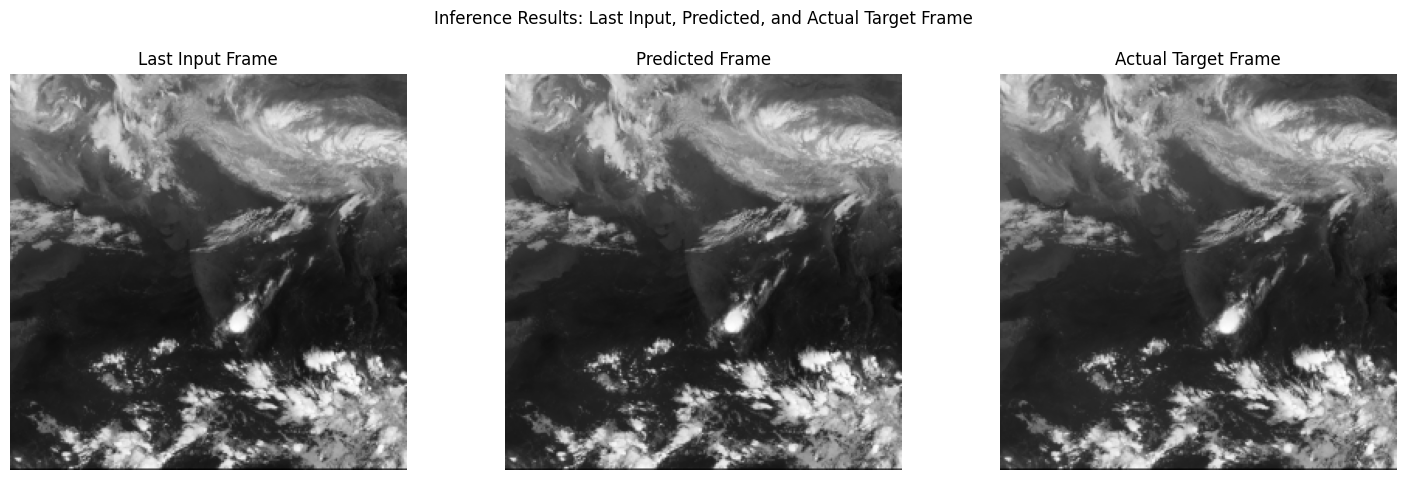


--- Predicted Frames Summary (after inference) ---
Min predicted value: 0.0527
Max predicted value: 0.9902
Mean predicted value: 0.3772
Predicted standard deviation: 0.2205

--- Actual Target Image Summary ---
Min actual value: 0.0157
Max actual value: 0.9804
Mean actual value: 0.3571
Actual standard deviation: 0.2188


In [319]:
logging.info("\n--- Demonstrating Inference ---")

# Load the best model
inference_model = ConvLSTMModel(dropout_rate=DROPOUT_RATE).to(DEVICE)
best_model_path = os.path.join(CHKPOINT_DIR, "best_model.pth")
if os.path.exists(best_model_path):
    # Load the entire checkpoint dictionary
    checkpoint = torch.load(best_model_path)
    # Extract the model's state_dict from the checkpoint
    # Use strict=False to handle architectural mismatches if the model definition changed after saving.
    inference_model.load_state_dict(checkpoint["model"], strict=False)
    logging.warning("Model loaded with strict=False due to potential architectural changes. "
                    "Missing or mismatched keys were ignored. For full compatibility, consider "
                    "re-training the model with the current architecture if this is not intended.")
    logging.info("Loaded best model for inference.")
else:
    logging.warning("Best model not found. Training might not have completed or saved a best model.")

# Get a sample input sequence from the test set
# This assumes `test_paths` was populated by `run_experiment`
if 'test_paths' in globals() and len(test_paths) >= SEQ_LEN + PRED_STEPS:
    sample_input_paths = test_paths[0:SEQ_LEN]
    actual_target_path = test_paths[SEQ_LEN]

    logging.info(f"Sample Input Paths for Inference: {sample_input_paths}")
    logging.info(f"Actual Target Path for Comparison: {actual_target_path}")

    # predicted_frames is now a torch.Tensor
    predicted_frames = inference(inference_model, sample_input_paths, DEVICE)

    # Display the last input frame, the predicted frame, and the actual target frame
    last_input_img = cv2.resize(cv2.imread(sample_input_paths[-1], cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA) / 255.0
    actual_target_img = cv2.resize(cv2.imread(actual_target_path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA) / 255.0

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(last_input_img, cmap='gray')
    plt.title('Last Input Frame')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    # Convert predicted_frames to numpy only for plotting
    plt.imshow(predicted_frames.numpy() if PRED_STEPS == 1 else predicted_frames[0].numpy(), cmap='gray')
    plt.title('Predicted Frame')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(actual_target_img, cmap='gray')
    plt.title('Actual Target Frame')
    plt.axis('off')

    plt.suptitle('Inference Results: Last Input, Predicted, and Actual Target Frame')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print('\n--- Predicted Frames Summary (after inference) ---')
    # Use predicted_frames (which is already a tensor) directly for statistics
    print(f'Min predicted value: {predicted_frames.min():.4f}')
    print(f'Max predicted value: {predicted_frames.max():.4f}')
    print(f'Mean predicted value: {predicted_frames.mean():.4f}')
    print(f'Predicted standard deviation: {predicted_frames.std():.4f}')

    # Also print summary for actual target image for comparison
    print('\n--- Actual Target Image Summary ---')
    actual_target_tensor = torch.tensor(actual_target_img, dtype=torch.float32)
    print(f'Min actual value: {actual_target_tensor.min():.4f}')
    print(f'Max actual value: {actual_target_tensor.max():.4f}')
    print(f'Mean actual value: {actual_target_tensor.mean():.4f}')
    print(f'Actual standard deviation: {actual_target_tensor.std():.4f}')

else:
    logging.error("Not enough test images to demonstrate inference with SEQ_LEN and PRED_STEPS.")